# Merged Human vs Non-Human

Bu notebook `NIGENS + ESC-50 + TESS` uzerinden ayri bir birlesik deney kurar.
Mevcut NIGENS baseline notebook'una dokunmaz.

## 1. Imports

In [1]:
import random
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from scipy.signal import butter, fftconvolve, sosfiltfilt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_SPLIT = True
except ImportError:
    StratifiedGroupKFold = None
    HAS_STRATIFIED_GROUP_SPLIT = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 2. Config

In [2]:
PROJECT_ROOT = Path(r"C:\projs\echo_swarm2")
NIGENS_ROOT = PROJECT_ROOT / "dataset" / "nigens" / "NIGENS" / "NIGENS"
ESC50_ROOT = PROJECT_ROOT / "dataset" / "esc-50" / "ESC-50-master"
ESC50_AUDIO_DIR = ESC50_ROOT / "audio"
ESC50_META_PATH = ESC50_ROOT / "meta" / "esc50.csv"
TESS_ROOT = PROJECT_ROOT / "dataset" / "tess" / "doi-10.5683-sp2-e8h2mf"

QUICK_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_quick_test"
QUICK_TEST_MANIFEST = QUICK_TEST_ROOT / "manifest.csv"
RUBBLE_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_rubble_test"
RUBBLE_TEST_MANIFEST = RUBBLE_TEST_ROOT / "manifest.csv"

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODELS_DIR / "merged_human_nonhuman_best.pt"

NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.20
SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.5
CLIP_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)
BATCH_SIZE = 32
NUM_EPOCHS = 24
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
LOWPASS_PROB = 0.45
NOISE_PROB = 0.45
REVERB_PROB = 0.20
TESS_MAX_WORDS_PER_SPEAKER = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Model path: {MODEL_PATH}")
print(f"StratifiedGroupKFold available: {HAS_STRATIFIED_GROUP_SPLIT}")


Device: cuda
Model path: C:\projs\echo_swarm2\models\merged_human_nonhuman_best.pt
StratifiedGroupKFold available: True


## 3. Curated Label Design

In [3]:
NIGENS_HUMAN_CLASSES = [
    "femaleScream",
    "maleScream",
    "femaleSpeech",
    "maleSpeech",
]

NIGENS_NON_HUMAN_CLASSES = [
    "alarm",
    "crash",
    "dog",
    "engine",
    "fire",
    "knock",
    "phone",
]

ESC50_HUMAN_CLASSES = [
    "breathing",
    "coughing",
    "laughing",
    "sneezing",
    "snoring",
]

ESC50_NON_HUMAN_CLASSES = [
    "airplane",
    "car_horn",
    "cat",
    "chainsaw",
    "church_bells",
    "clock_alarm",
    "cow",
    "crackling_fire",
    "crow",
    "dog",
    "door_wood_knock",
    "engine",
    "frog",
    "glass_breaking",
    "hand_saw",
    "helicopter",
    "hen",
    "pig",
    "rooster",
    "sheep",
    "siren",
    "train",
    "vacuum_cleaner",
    "washing_machine",
]

EXCLUDED_KEYWORDS = [
    "baby",
    "crying_baby",
    "footsteps",
    "piano",
    "general",
    "song",
    "music",
]

LABEL_TO_IDX = {"NON_HUMAN": 0, "HUMAN": 1}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

display(
    pd.DataFrame(
        [
            {"dataset": "NIGENS", "target_label": "HUMAN", "classes": ", ".join(NIGENS_HUMAN_CLASSES)},
            {"dataset": "NIGENS", "target_label": "NON_HUMAN", "classes": ", ".join(NIGENS_NON_HUMAN_CLASSES)},
            {"dataset": "ESC-50", "target_label": "HUMAN", "classes": ", ".join(ESC50_HUMAN_CLASSES)},
            {"dataset": "ESC-50", "target_label": "NON_HUMAN", "classes": ", ".join(ESC50_NON_HUMAN_CLASSES)},
            {"dataset": "TESS", "target_label": "HUMAN", "classes": "all speech wav files (sampled by word)"},
        ]
    )
)
print(f"Excluded keywords: {EXCLUDED_KEYWORDS}")


,dataset,target_label,classes
0,NIGENS,HUMAN,"femaleScream, maleScream, femaleSpeech, maleSp..."
1,NIGENS,NON_HUMAN,"alarm, crash, dog, engine, fire, knock, phone"
2,ESC-50,HUMAN,"breathing, coughing, laughing, sneezing, snoring"
3,ESC-50,NON_HUMAN,"airplane, car_horn, cat, chainsaw, church_bell..."
4,TESS,HUMAN,all speech wav files (sampled by word)


Excluded keywords: ['baby', 'crying_baby', 'footsteps', 'piano', 'general', 'song', 'music']


## 4. Collect NIGENS Records

In [4]:
def collect_nigens_records(root: Path) -> pd.DataFrame:
    records = []
    for source_class in NIGENS_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            records.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "HUMAN",
                    "label_idx": LABEL_TO_IDX["HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )

    for source_class in NIGENS_NON_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            records.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "NON_HUMAN",
                    "label_idx": LABEL_TO_IDX["NON_HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )

    df = pd.DataFrame(records)
    if df.empty:
        raise RuntimeError("NIGENS kayitlari toplanamadi.")
    return df


nigens_df = collect_nigens_records(NIGENS_ROOT)
display(
    nigens_df.groupby(["target_label", "source_class"]).size().reset_index(name="count").sort_values(["target_label", "source_class"])
)


,target_label,source_class,count
0,HUMAN,femaleScream,45
1,HUMAN,femaleSpeech,40
2,HUMAN,maleScream,31
3,HUMAN,maleSpeech,40
4,NON_HUMAN,alarm,50
5,NON_HUMAN,crash,50
6,NON_HUMAN,dog,45
7,NON_HUMAN,engine,39
8,NON_HUMAN,fire,51
9,NON_HUMAN,knock,40


## 5. Collect ESC-50 Records

In [5]:
def collect_esc50_records(meta_path: Path, audio_dir: Path) -> pd.DataFrame:
    meta_df = pd.read_csv(meta_path)
    allowed_categories = set(ESC50_HUMAN_CLASSES + ESC50_NON_HUMAN_CLASSES)
    meta_df = meta_df[meta_df["category"].isin(allowed_categories)].copy()
    meta_df["target_label"] = np.where(meta_df["category"].isin(ESC50_HUMAN_CLASSES), "HUMAN", "NON_HUMAN")
    meta_df["label_idx"] = meta_df["target_label"].map(LABEL_TO_IDX)
    meta_df["path"] = meta_df["filename"].apply(lambda name: str(audio_dir / name))
    meta_df["source_dataset"] = "ESC-50"
    meta_df["source_class"] = meta_df["category"]
    meta_df["group_id"] = meta_df["src_file"].astype(str).apply(lambda value: f"ESC50_{value}")
    if (~meta_df["path"].apply(lambda value: Path(value).exists())).any():
        raise FileNotFoundError("ESC-50 audio dosyalarindan bazilari eksik.")
    return meta_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]].reset_index(drop=True)


esc50_df = collect_esc50_records(ESC50_META_PATH, ESC50_AUDIO_DIR)
display(
    esc50_df.groupby(["target_label", "source_class"]).size().reset_index(name="count").sort_values(["target_label", "source_class"])
)


,target_label,source_class,count
0,HUMAN,breathing,40
1,HUMAN,coughing,40
2,HUMAN,laughing,40
3,HUMAN,sneezing,40
4,HUMAN,snoring,40
5,NON_HUMAN,airplane,40
6,NON_HUMAN,car_horn,40
7,NON_HUMAN,cat,40
8,NON_HUMAN,chainsaw,40
9,NON_HUMAN,church_bells,40


## 6. Collect TESS Records

In [6]:
def collect_tess_records(root: Path, max_words_per_speaker: int = TESS_MAX_WORDS_PER_SPEAKER, seed: int = SEED) -> pd.DataFrame:
    wav_paths = sorted(root.glob("*.wav"))
    if not wav_paths:
        raise RuntimeError("TESS wav dosyalari bulunamadi.")

    rows = []
    for wav_path in wav_paths:
        parts = wav_path.stem.split("_")
        if len(parts) < 3:
            continue
        speaker, word, emotion = parts[0], parts[1], parts[2]
        rows.append(
            {
                "path": str(wav_path),
                "source_dataset": "TESS",
                "source_class": "tess_speech",
                "target_label": "HUMAN",
                "label_idx": LABEL_TO_IDX["HUMAN"],
                "speaker": speaker,
                "word": word,
                "emotion": emotion,
                "group_id": f"TESS_{speaker}_{word}",
            }
        )

    tess_df = pd.DataFrame(rows)
    sampler = random.Random(seed)
    selected_groups = []
    for speaker, speaker_df in tess_df.groupby("speaker"):
        groups = sorted(speaker_df["group_id"].unique().tolist())
        selected_groups.extend(sampler.sample(groups, k=min(max_words_per_speaker, len(groups))))

    tess_df = tess_df[tess_df["group_id"].isin(selected_groups)].reset_index(drop=True)
    return tess_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]]


tess_df = collect_tess_records(TESS_ROOT)
print(f"Secilen TESS ornek sayisi: {len(tess_df)}")
print(f"Secilen TESS grup sayisi: {tess_df['group_id'].nunique()}")
display(tess_df.head())


Secilen TESS ornek sayisi: 896
Secilen TESS grup sayisi: 128


,path,source_dataset,source_class,target_label,label_idx,group_id
0,C:\projs\echo_swarm2\dataset\tess\doi-10.5683-...,TESS,tess_speech,HUMAN,1,TESS_OAF_bar
1,C:\projs\echo_swarm2\dataset\tess\doi-10.5683-...,TESS,tess_speech,HUMAN,1,TESS_OAF_bar
2,C:\projs\echo_swarm2\dataset\tess\doi-10.5683-...,TESS,tess_speech,HUMAN,1,TESS_OAF_bar
3,C:\projs\echo_swarm2\dataset\tess\doi-10.5683-...,TESS,tess_speech,HUMAN,1,TESS_OAF_bar
4,C:\projs\echo_swarm2\dataset\tess\doi-10.5683-...,TESS,tess_speech,HUMAN,1,TESS_OAF_bar


## 7. Merge and Inspect

In [7]:
merged_df = pd.concat([nigens_df, esc50_df, tess_df], ignore_index=True)
merged_df = merged_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f"Toplam secilen ornek sayisi: {len(merged_df)}")
display(
    merged_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count").sort_values(["source_dataset", "target_label"])
)
display(
    merged_df["target_label"].value_counts().rename_axis("target_label").reset_index(name="count").sort_values("target_label")
)


Toplam secilen ornek sayisi: 2527


,source_dataset,target_label,count
0,ESC-50,HUMAN,200
1,ESC-50,NON_HUMAN,960
2,NIGENS,HUMAN,156
3,NIGENS,NON_HUMAN,315
4,TESS,HUMAN,896


,target_label,count
1,HUMAN,1252
0,NON_HUMAN,1275


## 8. Stratified Group Split

In [8]:
def make_group_split(df: pd.DataFrame):
    if HAS_STRATIFIED_GROUP_SPLIT:
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, y=df["target_label"], groups=df["group_id"]))
    else:
        print("Uyari: StratifiedGroupKFold bulunamadi, GroupShuffleSplit fallback kullaniliyor.")
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, groups=df["group_id"]))
    return train_idx, val_idx


train_idx, val_idx = make_group_split(merged_df)
train_df = merged_df.iloc[train_idx].reset_index(drop=True)
val_df = merged_df.iloc[val_idx].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Train groups: {train_df['group_id'].nunique()}")
print(f"Val groups: {val_df['group_id'].nunique()}")

display(train_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count").sort_values(["source_dataset", "target_label"]))
display(val_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count").sort_values(["source_dataset", "target_label"]))


Train size: 2013
Val size: 514
Train groups: 1177
Val groups: 295


,source_dataset,target_label,count
0,ESC-50,HUMAN,163
1,ESC-50,NON_HUMAN,760
2,NIGENS,HUMAN,124
3,NIGENS,NON_HUMAN,252
4,TESS,HUMAN,714


,source_dataset,target_label,count
0,ESC-50,HUMAN,37
1,ESC-50,NON_HUMAN,200
2,NIGENS,HUMAN,32
3,NIGENS,NON_HUMAN,63
4,TESS,HUMAN,182


## 9. WAV Preprocess

In [9]:
def load_audio(path: str, target_sr: int = SAMPLE_RATE) -> np.ndarray:
    waveform, sr = librosa.load(path, sr=None, mono=True)
    waveform = waveform.astype(np.float32)
    if sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
    return waveform.astype(np.float32)


def crop_or_pad(waveform: np.ndarray, target_length: int = CLIP_SAMPLES, training: bool = False) -> np.ndarray:
    current_length = len(waveform)
    if current_length > target_length:
        start = random.randint(0, current_length - target_length) if training else (current_length - target_length) // 2
        waveform = waveform[start : start + target_length]
    elif current_length < target_length:
        pad_total = target_length - current_length
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        waveform = np.pad(waveform, (pad_left, pad_right), mode="constant")
    return waveform.astype(np.float32)


sample_wave = crop_or_pad(load_audio(train_df.loc[0, "path"]), training=False)
print(f"Ornek waveform boyutu: {sample_wave.shape}")
print(f"Sure (sn): {len(sample_wave) / SAMPLE_RATE:.2f}")


Ornek waveform boyutu: (24000,)
Sure (sn): 1.50


## 10. Robust Augment

In [10]:
def lowpass_filter(waveform: np.ndarray, sr: int = SAMPLE_RATE, cutoff_hz: float | None = None) -> np.ndarray:
    cutoff_hz = cutoff_hz or random.uniform(700.0, 4500.0)
    nyquist = sr / 2.0
    sos = butter(6, min(cutoff_hz / nyquist, 0.95), btype="low", output="sos")
    return sosfiltfilt(sos, waveform).astype(np.float32)


def build_impulse_response(sr: int = SAMPLE_RATE) -> np.ndarray:
    length = max(int(sr * 0.14), 8)
    t = np.linspace(0.0, 1.0, length, endpoint=False, dtype=np.float32)
    ir = np.exp(-8.0 * t)
    for pos, gain in zip([0, int(sr * 0.018), int(sr * 0.043), int(sr * 0.070)], [1.0, 0.32, 0.18, 0.08]):
        if pos < len(ir):
            ir[pos] += gain
    ir /= np.sum(np.abs(ir)) + 1e-8
    return ir.astype(np.float32)


def apply_reverb(waveform: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    ir = build_impulse_response(sr)
    return fftconvolve(waveform, ir, mode="full")[: len(waveform)].astype(np.float32)


def add_noise(waveform: np.ndarray) -> np.ndarray:
    snr_db = random.uniform(6.0, 18.0)
    clean_rms = np.sqrt(np.mean(waveform**2) + 1e-8)
    noise = np.random.normal(0.0, 1.0, size=waveform.shape).astype(np.float32)
    noise_rms = np.sqrt(np.mean(noise**2) + 1e-8)
    desired_noise_rms = clean_rms / (10 ** (snr_db / 20.0))
    noise = noise * (desired_noise_rms / noise_rms)
    return (waveform + noise).astype(np.float32)


def augment_waveform(waveform: np.ndarray) -> np.ndarray:
    augmented = waveform.copy()
    if random.random() < LOWPASS_PROB:
        augmented = lowpass_filter(augmented)
    if random.random() < REVERB_PROB:
        augmented = apply_reverb(augmented)
    if random.random() < NOISE_PROB:
        augmented = add_noise(augmented)
    peak = np.max(np.abs(augmented)) + 1e-8
    augmented = 0.95 * augmented / peak
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)


## 11. Log-Mel Spectrogram

Log-mel boyutu: (64, 94)


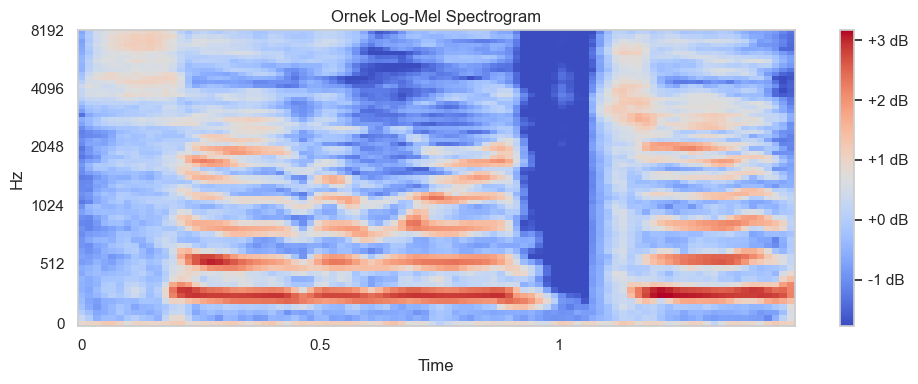

In [11]:
def waveform_to_logmel(
    waveform: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_mels: int = N_MELS,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
) -> np.ndarray:
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return ((log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)).astype(np.float32)


example_logmel = waveform_to_logmel(sample_wave)
print(f"Log-mel boyutu: {example_logmel.shape}")
plt.figure(figsize=(10, 4))
librosa.display.specshow(example_logmel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title("Ornek Log-Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()


## 12. Dataset and DataLoader

In [12]:
class MergedAudioDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, training: bool = False):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.training = training

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        waveform = crop_or_pad(load_audio(row["path"]), training=self.training)
        if self.training:
            waveform = augment_waveform(waveform)
        feature = torch.tensor(waveform_to_logmel(waveform), dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return feature, label


train_dataset = MergedAudioDataset(train_df, training=True)
val_dataset = MergedAudioDataset(val_df, training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

sample_feature, sample_label = train_dataset[0]
print(f"Feature shape: {sample_feature.shape}")
print(f"Label: {sample_label.item()} -> {IDX_TO_LABEL[sample_label.item()]}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Feature shape: torch.Size([1, 64, 94])
Label: 1 -> HUMAN
Train batches: 63 | Val batches: 17


## 13. Model and Training Utilities

In [13]:
class SmallAudioCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.15),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model = SmallAudioCNN(num_classes=len(LABEL_TO_IDX)).to(DEVICE)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(LABEL_TO_IDX.values())),
    y=train_df["label_idx"].to_numpy(),
)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

display(
    pd.DataFrame(
        {
            "label_idx": sorted(LABEL_TO_IDX.values()),
            "label_name": [IDX_TO_LABEL[idx] for idx in sorted(LABEL_TO_IDX.values())],
            "weight": class_weights,
        }
    )
)


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for features, labels in dataloader:
        features = features.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            logits = model(features)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(dataloader.dataset)
    epoch_acc = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


,label_idx,label_name,weight
0,0,NON_HUMAN,0.994565
1,1,HUMAN,1.005495


## 14. Train and Save Best Model

Epoch 01/24 | train_loss=0.5677 train_acc=0.7308 | val_loss=0.4142 val_acc=0.8132 | val_macro_f1=0.8129 val_human_recall=0.7888
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_best.pt
Epoch 02/24 | train_loss=0.4282 train_acc=0.8107 | val_loss=0.3741 val_acc=0.8560 | val_macro_f1=0.8536 val_human_recall=0.7450
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_best.pt
Epoch 03/24 | train_loss=0.3722 train_acc=0.8410 | val_loss=0.4344 val_acc=0.7840 | val_macro_f1=0.7821 val_human_recall=0.9004
Epoch 04/24 | train_loss=0.3854 train_acc=0.8311 | val_loss=0.3111 val_acc=0.8619 | val_macro_f1=0.8605 val_human_recall=0.7809
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_best.pt
Epoch 05/24 | train_loss=0.3356 train_acc=0.8579 | val_loss=0.3203 val_acc=0.8696 | val_macro_f1=0.8685 val_human_recall=0.7928
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhu

,epoch,train_loss,train_acc,val_loss,val_acc,val_macro_f1,val_human_recall
0,1,0.567712,0.730750,0.414190,0.813230,0.812887,0.788845
1,2,0.428194,0.810730,0.374074,0.856031,0.853618,0.745020
2,3,0.372158,0.841033,0.434447,0.784047,0.782066,0.900398
3,4,0.385429,0.831098,0.311098,0.861868,0.860494,0.780876
4,5,0.335636,0.857923,0.320280,0.869650,0.868454,0.792829
5,6,0.344577,0.860407,0.407386,0.834630,0.829033,0.669323
6,7,0.332125,0.858917,0.312542,0.873541,0.870790,0.745020
7,8,0.314539,0.866865,0.288453,0.873541,0.871081,0.752988
8,9,0.320804,0.861401,0.288265,0.861868,0.860494,0.780876
9,10,0.326021,0.863885,0.286682,0.867704,0.866115,0.776892


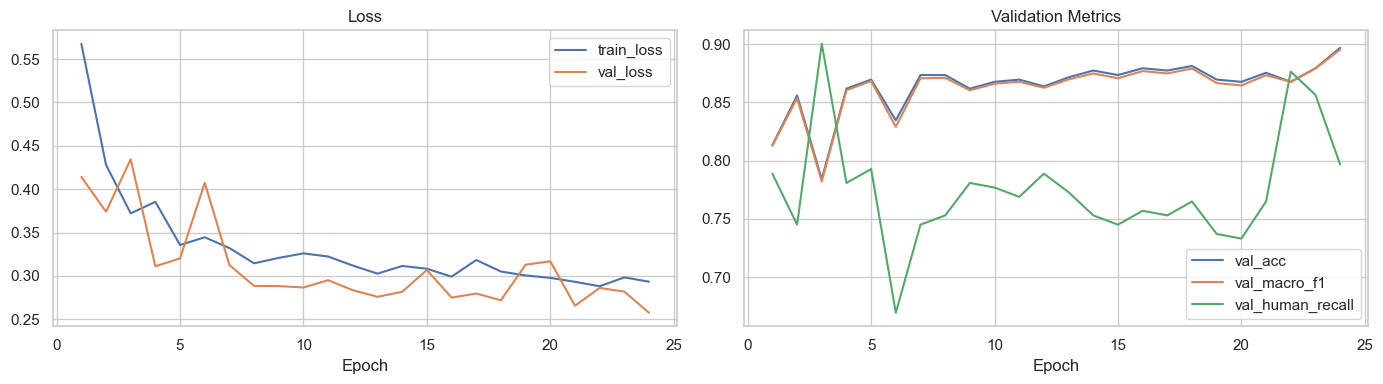

Best val macro F1: 0.8954
Best val HUMAN recall: 0.7968


In [14]:
history = []
best_state_dict = None
best_val_macro_f1 = -1.0
best_val_human_recall = -1.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc, val_labels, val_preds = run_epoch(model, val_loader, criterion, optimizer=None)

    val_macro_f1 = f1_score(val_labels, val_preds, average="macro")
    val_human_recall = recall_score(val_labels, val_preds, pos_label=LABEL_TO_IDX["HUMAN"])

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
            "val_human_recall": val_human_recall,
        }
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"val_macro_f1={val_macro_f1:.4f} val_human_recall={val_human_recall:.4f}"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_val_human_recall = val_human_recall
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        torch.save(
            {
                "model_state_dict": best_state_dict,
                "label_to_idx": LABEL_TO_IDX,
                "config": {
                    "sample_rate": SAMPLE_RATE,
                    "clip_seconds": CLIP_SECONDS,
                    "n_mels": N_MELS,
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                },
            },
            MODEL_PATH,
        )
        patience_counter = 0
        print(f"  -> Yeni en iyi model kaydedildi: {MODEL_PATH}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping tetiklendi (patience={PATIENCE}).")
        break

if best_state_dict is None:
    raise RuntimeError("Egitim sirasinda en iyi model olusturulamadi.")

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
axes[1].plot(history_df["epoch"], history_df["val_human_recall"], label="val_human_recall")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Best val macro F1: {best_val_macro_f1:.4f}")
print(f"Best val HUMAN recall: {best_val_human_recall:.4f}")


## 15. Validation Evaluation

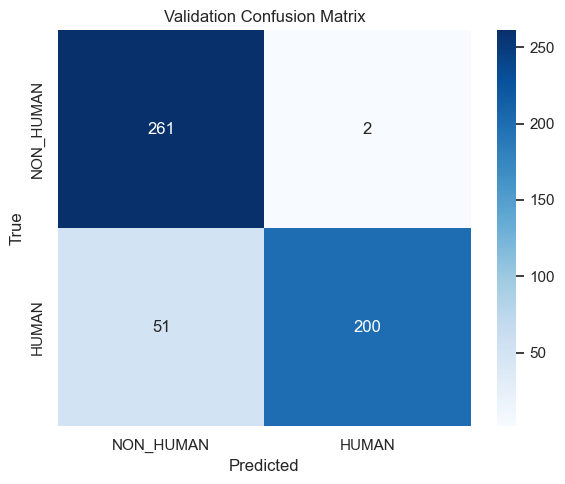

,precision,recall,f1-score,support
NON_HUMAN,0.836538,0.992395,0.907826,263.000000
HUMAN,0.990099,0.796813,0.883002,251.000000
accuracy,0.896887,0.896887,0.896887,0.896887
macro avg,0.913319,0.894604,0.895414,514.000000
weighted avg,0.911526,0.896887,0.895704,514.000000


,source_dataset,accuracy
0,ESC-50,0.843882
1,NIGENS,0.831579
2,TESS,1.000000


HUMAN recall: 0.7968


In [15]:
def predict_dataframe(model, dataframe: pd.DataFrame):
    dataset = MergedAudioDataset(dataframe, training=False)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    model.eval()
    probs_list, preds_list, labels_list = [], [], []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE, non_blocking=True)
            logits = model(features)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            probs_list.extend(probs[:, LABEL_TO_IDX["HUMAN"]].cpu().numpy().tolist())
            preds_list.extend(preds.cpu().numpy().tolist())
            labels_list.extend(labels.numpy().tolist())
    return np.array(labels_list), np.array(preds_list), np.array(probs_list)


val_labels, val_preds, _ = predict_dataframe(model, val_df)
cm = confusion_matrix(val_labels, val_preds, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]], yticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

report_dict = classification_report(
    val_labels,
    val_preds,
    labels=[0, 1],
    target_names=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
    digits=4,
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report_dict).transpose())

val_eval_df = val_df.copy()
val_eval_df["pred_idx"] = val_preds
val_eval_df["pred_label"] = [IDX_TO_LABEL[idx] for idx in val_preds]
dataset_breakdown = (
    val_eval_df.assign(is_correct=val_eval_df["label_idx"] == val_eval_df["pred_idx"])
    .groupby("source_dataset")["is_correct"]
    .mean()
    .reset_index(name="accuracy")
    .sort_values("source_dataset")
)
display(dataset_breakdown)
print(f"HUMAN recall: {report_dict['HUMAN']['recall']:.4f}")


## 16. Demo Benchmark (Quick + Rubble)

In [16]:
def load_checkpoint_for_inference(model_path: Path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    inference_model = SmallAudioCNN(num_classes=len(checkpoint["label_to_idx"])).to(DEVICE)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()
    return inference_model, checkpoint


def predict_single_wav(wav_path: str, model_path: Path = MODEL_PATH):
    inference_model, checkpoint = load_checkpoint_for_inference(model_path)
    waveform = load_audio(wav_path, target_sr=checkpoint["config"]["sample_rate"])
    waveform = crop_or_pad(waveform, target_length=int(checkpoint["config"]["sample_rate"] * checkpoint["config"]["clip_seconds"]), training=False)
    logmel = waveform_to_logmel(
        waveform,
        sr=checkpoint["config"]["sample_rate"],
        n_mels=checkpoint["config"]["n_mels"],
        n_fft=checkpoint["config"]["n_fft"],
        hop_length=checkpoint["config"]["hop_length"],
    )
    feature = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = inference_model(feature)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    predicted_idx = int(np.argmax(probs))
    return {
        "wav_path": wav_path,
        "predicted_label": IDX_TO_LABEL[predicted_idx],
        "human_probability": float(probs[LABEL_TO_IDX["HUMAN"]]),
        "non_human_probability": float(probs[LABEL_TO_IDX["NON_HUMAN"]]),
    }


def run_demo_benchmark(manifest_path: Path, folder_root: Path) -> pd.DataFrame:
    manifest_df = pd.read_csv(manifest_path)
    rows = []
    for _, row in manifest_df.iterrows():
        if "variant_path" in manifest_df.columns:
            wav_path = row["variant_path"]
            file_name = Path(wav_path).name
        else:
            subfolder = "human" if row["target_label"] == "HUMAN" else "non_human"
            file_name = row["demo_name"]
            wav_path = str(folder_root / subfolder / file_name)
        pred = predict_single_wav(wav_path)
        pred["file_name"] = file_name
        pred["target_label"] = row["target_label"]
        rows.append(pred)
    results_df = pd.DataFrame(rows)
    results_df["is_correct"] = results_df["predicted_label"] == results_df["target_label"]
    return results_df[["file_name", "target_label", "predicted_label", "human_probability", "non_human_probability", "is_correct"]]


if QUICK_TEST_MANIFEST.exists():
    quick_results_df = run_demo_benchmark(QUICK_TEST_MANIFEST, QUICK_TEST_ROOT)
    display(quick_results_df)
    print(f"Quick test accuracy: {quick_results_df['is_correct'].mean():.4f}")
    print(f"Quick HUMAN recall: {quick_results_df.loc[quick_results_df['target_label'] == 'HUMAN', 'predicted_label'].eq('HUMAN').mean():.4f}")
else:
    print("Quick test manifest bulunamadi.")

if RUBBLE_TEST_MANIFEST.exists():
    rubble_results_df = run_demo_benchmark(RUBBLE_TEST_MANIFEST, RUBBLE_TEST_ROOT)
    display(rubble_results_df)
    print(f"Rubble test accuracy: {rubble_results_df['is_correct'].mean():.4f}")
    print(f"Rubble HUMAN recall: {rubble_results_df.loc[rubble_results_df['target_label'] == 'HUMAN', 'predicted_label'].eq('HUMAN').mean():.4f}")
else:
    print("Rubble test manifest bulunamadi.")


,file_name,target_label,predicted_label,human_probability,non_human_probability,is_correct
0,human_01_femaleSpeech.wav,HUMAN,HUMAN,0.963776,0.036224,True
1,human_02_maleSpeech.wav,HUMAN,NON_HUMAN,0.497718,0.502282,False
2,human_03_femaleScream.wav,HUMAN,NON_HUMAN,0.345237,0.654763,False
3,human_04_maleScream.wav,HUMAN,NON_HUMAN,0.432492,0.567508,False
4,nonhuman_01_alarm.wav,NON_HUMAN,NON_HUMAN,0.151848,0.848152,True
5,nonhuman_02_dog.wav,NON_HUMAN,NON_HUMAN,0.385299,0.614701,True
6,nonhuman_03_engine.wav,NON_HUMAN,NON_HUMAN,0.103915,0.896085,True
7,nonhuman_04_fire.wav,NON_HUMAN,NON_HUMAN,0.032113,0.967887,True


Quick test accuracy: 0.6250
Quick HUMAN recall: 0.2500


,file_name,target_label,predicted_label,human_probability,non_human_probability,is_correct
0,human_01_femaleSpeech_rubble.wav,HUMAN,HUMAN,0.981235,0.018765,True
1,human_02_maleSpeech_rubble.wav,HUMAN,HUMAN,0.501398,0.498602,True
2,human_03_femaleScream_rubble.wav,HUMAN,NON_HUMAN,0.174336,0.825664,False
3,human_04_maleScream_rubble.wav,HUMAN,NON_HUMAN,0.411247,0.588753,False
4,nonhuman_01_alarm_rubble.wav,NON_HUMAN,NON_HUMAN,0.343622,0.656378,True
5,nonhuman_02_dog_rubble.wav,NON_HUMAN,NON_HUMAN,0.377915,0.622085,True
6,nonhuman_03_engine_rubble.wav,NON_HUMAN,NON_HUMAN,0.122078,0.877922,True
7,nonhuman_04_fire_rubble.wav,NON_HUMAN,NON_HUMAN,0.172535,0.827465,True


Rubble test accuracy: 0.7500
Rubble HUMAN recall: 0.5000


## 17. Single WAV Inference

In [17]:
INFER_WAV_PATH = r""

if INFER_WAV_PATH:
    inference_result = predict_single_wav(INFER_WAV_PATH)
    display(pd.DataFrame([inference_result]))
else:
    print("Inference icin INFER_WAV_PATH degiskenine bir .wav dosyasi yolu verin.")


Inference icin INFER_WAV_PATH degiskenine bir .wav dosyasi yolu verin.


## Report Comparison

,experiment_name,project_name,datasets_used,val_accuracy,val_macro_f1,human_recall,quick_test_accuracy,quick_test_human_recall,rubble_test_accuracy,rubble_test_human_recall
0,echo_swarm2_merged_human_vs_nonhuman,echo_swarm2,NIGENS + ESC-50 + TESS,0.896887,0.895414,0.796813,0.625,0.25,0.75,0.50
1,echo_swarm2_nigens_human_vs_nonhuman,echo_swarm2,NIGENS,0.916031,0.893739,0.967742,0.875,1.00,0.50,0.25
2,echo_swarm_scream_baseline,echo_swarm,human_screaming_detection,0.806400,0.805600,0.894700,NaN,NaN,NaN,NaN


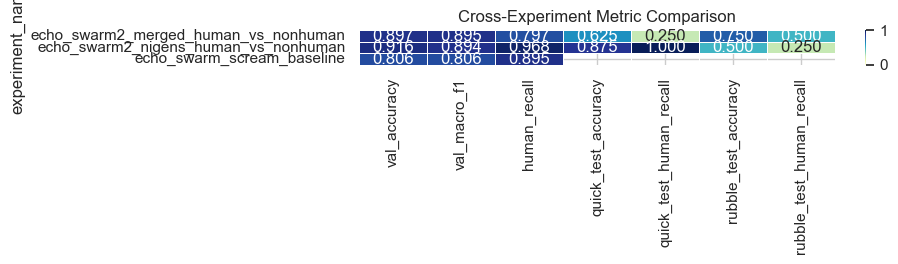

Comparison CSV updated: C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv


In [18]:
# EXPERIMENT_COMPARISON_SECTION
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

COMPARISON_CSV = Path(r"C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv")
COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)
COMPARISON_PNG = COMPARISON_CSV.with_name("cross_project_experiment_comparison_heatmap.png")

def upsert_experiment_row(row: dict, csv_path: Path = COMPARISON_CSV) -> pd.DataFrame:
    new_row = pd.DataFrame([row])
    if csv_path.exists():
        current_df = pd.read_csv(csv_path)
    else:
        current_df = pd.DataFrame(columns=new_row.columns)

    for col in new_row.columns:
        if col not in current_df.columns:
            current_df[col] = pd.NA
    for col in current_df.columns:
        if col not in new_row.columns:
            new_row[col] = pd.NA

    new_row = new_row[current_df.columns]
    current_df = current_df[current_df["experiment_name"] != row["experiment_name"]]
    current_df = pd.concat([current_df, new_row], ignore_index=True)
    current_df.to_csv(csv_path, index=False)
    return current_df

def render_comparison(df: pd.DataFrame) -> None:
    ordered_cols = [
        "experiment_name",
        "project_name",
        "datasets_used",
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    show_cols = [col for col in ordered_cols if col in df.columns]
    display(df[show_cols].sort_values("experiment_name").reset_index(drop=True))

    metric_cols = [
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    metric_cols = [col for col in metric_cols if col in df.columns and df[col].notna().any()]
    if not metric_cols:
        return

    heatmap_df = df[["experiment_name"] + metric_cols].copy()
    heatmap_df[metric_cols] = heatmap_df[metric_cols].apply(pd.to_numeric, errors="coerce")
    heatmap_df = heatmap_df.set_index("experiment_name").sort_index()

    plt.figure(figsize=(max(8, len(metric_cols) * 1.4), max(2.8, len(heatmap_df) * 0.7)))
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title("Cross-Experiment Metric Comparison")
    plt.tight_layout()
    plt.savefig(COMPARISON_PNG, dpi=180, bbox_inches="tight")
    plt.show()

quick_acc = float(quick_results_df["is_correct"].mean()) if "quick_results_df" in globals() else pd.NA
quick_hrec = (
    float(quick_results_df.loc[quick_results_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean())
    if "quick_results_df" in globals()
    else pd.NA
)
rubble_acc = float(rubble_results_df["is_correct"].mean()) if "rubble_results_df" in globals() else pd.NA
rubble_hrec = (
    float(rubble_results_df.loc[rubble_results_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean())
    if "rubble_results_df" in globals()
    else pd.NA
)

summary_row = {
    "experiment_name": "echo_swarm2_merged_human_vs_nonhuman",
    "project_name": "echo_swarm2",
    "notebook_path": r"C:\projs\echo_swarm2\notebooks\merged_human_vs_nonhuman.ipynb",
    "datasets_used": "NIGENS + ESC-50 + TESS",
    "human_definition": "NIGENS speech/scream + ESC50 breathing/coughing/laughing/sneezing/snoring + TESS speech",
    "nonhuman_definition": "NIGENS alarm/crash/dog/engine/fire/knock/phone + curated ESC50 nonhuman classes",
    "val_accuracy": float((val_labels == val_preds).mean()),
    "val_macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "human_recall": float(report_dict["HUMAN"]["recall"]),
    "quick_test_accuracy": quick_acc,
    "quick_test_human_recall": quick_hrec,
    "rubble_test_accuracy": rubble_acc,
    "rubble_test_human_recall": rubble_hrec,
}

comparison_df = upsert_experiment_row(summary_row)
render_comparison(comparison_df)
print(f"Comparison CSV updated: {COMPARISON_CSV}")
